# Importing Data and Libraries

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("online_shoppers_intention.csv") 

In [9]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# Exploratory Data Analysis (EDA)

## Dataset Structure

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [15]:
df.dtypes  # Check data types
df.nunique() 

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [171]:
# continuous variables
continuous = ["ProductRelated_Duration", "BounceRates", "ExitRates", 
              "Administrative_Duration", "Informational_Duration", "PageValues",
              "ProductRelated"]

# discrete variables 
discrete = ["Administrative", "Informational", "SpecialDay", "OperatingSystems", 
            "Browser", "Region", "TrafficType"]

# ordinal variables 
ordinal = ["Month"]

# nominal variables
nominal = ["VisitorType", "Weekend"]
target = ["Revenue"]

# note - treating the following discrete vars as continuous:
# "Administrative_Duration", "Informational_Duration", "PageValues", "ProductRelated"

## Summary Statistics

In [104]:
df[continuous].describe()

,ProductRelated_Duration,BounceRates,ExitRates,Administrative_Duration,Informational_Duration,PageValues,ProductRelated
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,1194.746220,0.022191,0.043073,80.818611,34.472398,5.889258,31.731468
std,1913.669288,0.048488,0.048597,176.779107,140.749294,18.568437,44.475503
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,184.137500,0.000000,0.014286,0.000000,0.000000,0.000000,7.000000
50%,598.936905,0.003112,0.025156,7.500000,0.000000,0.000000,18.000000
75%,1464.157214,0.016813,0.050000,93.256250,0.000000,0.000000,38.000000
max,63973.522230,0.200000,0.200000,3398.750000,2549.375000,361.763742,705.000000


In [106]:
df[discrete].describe()

,Administrative,Informational,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,0.503569,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,1.270156,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,24.000000,1.000000,8.000000,13.000000,9.000000,20.000000


In [108]:
df[discrete].nunique() 

Administrative      27
Informational       17
SpecialDay           6
OperatingSystems     8
Browser             13
Region               9
TrafficType         20
dtype: int64

In [173]:
df[ordinal + nominal + target].describe()

,Month,VisitorType,Weekend,Revenue
count,12330,12330,12330,12330
unique,10,3,2,2
top,May,Returning_Visitor,False,False
freq,3364,10551,9462,10422


## Univariate Distribution Visualizations

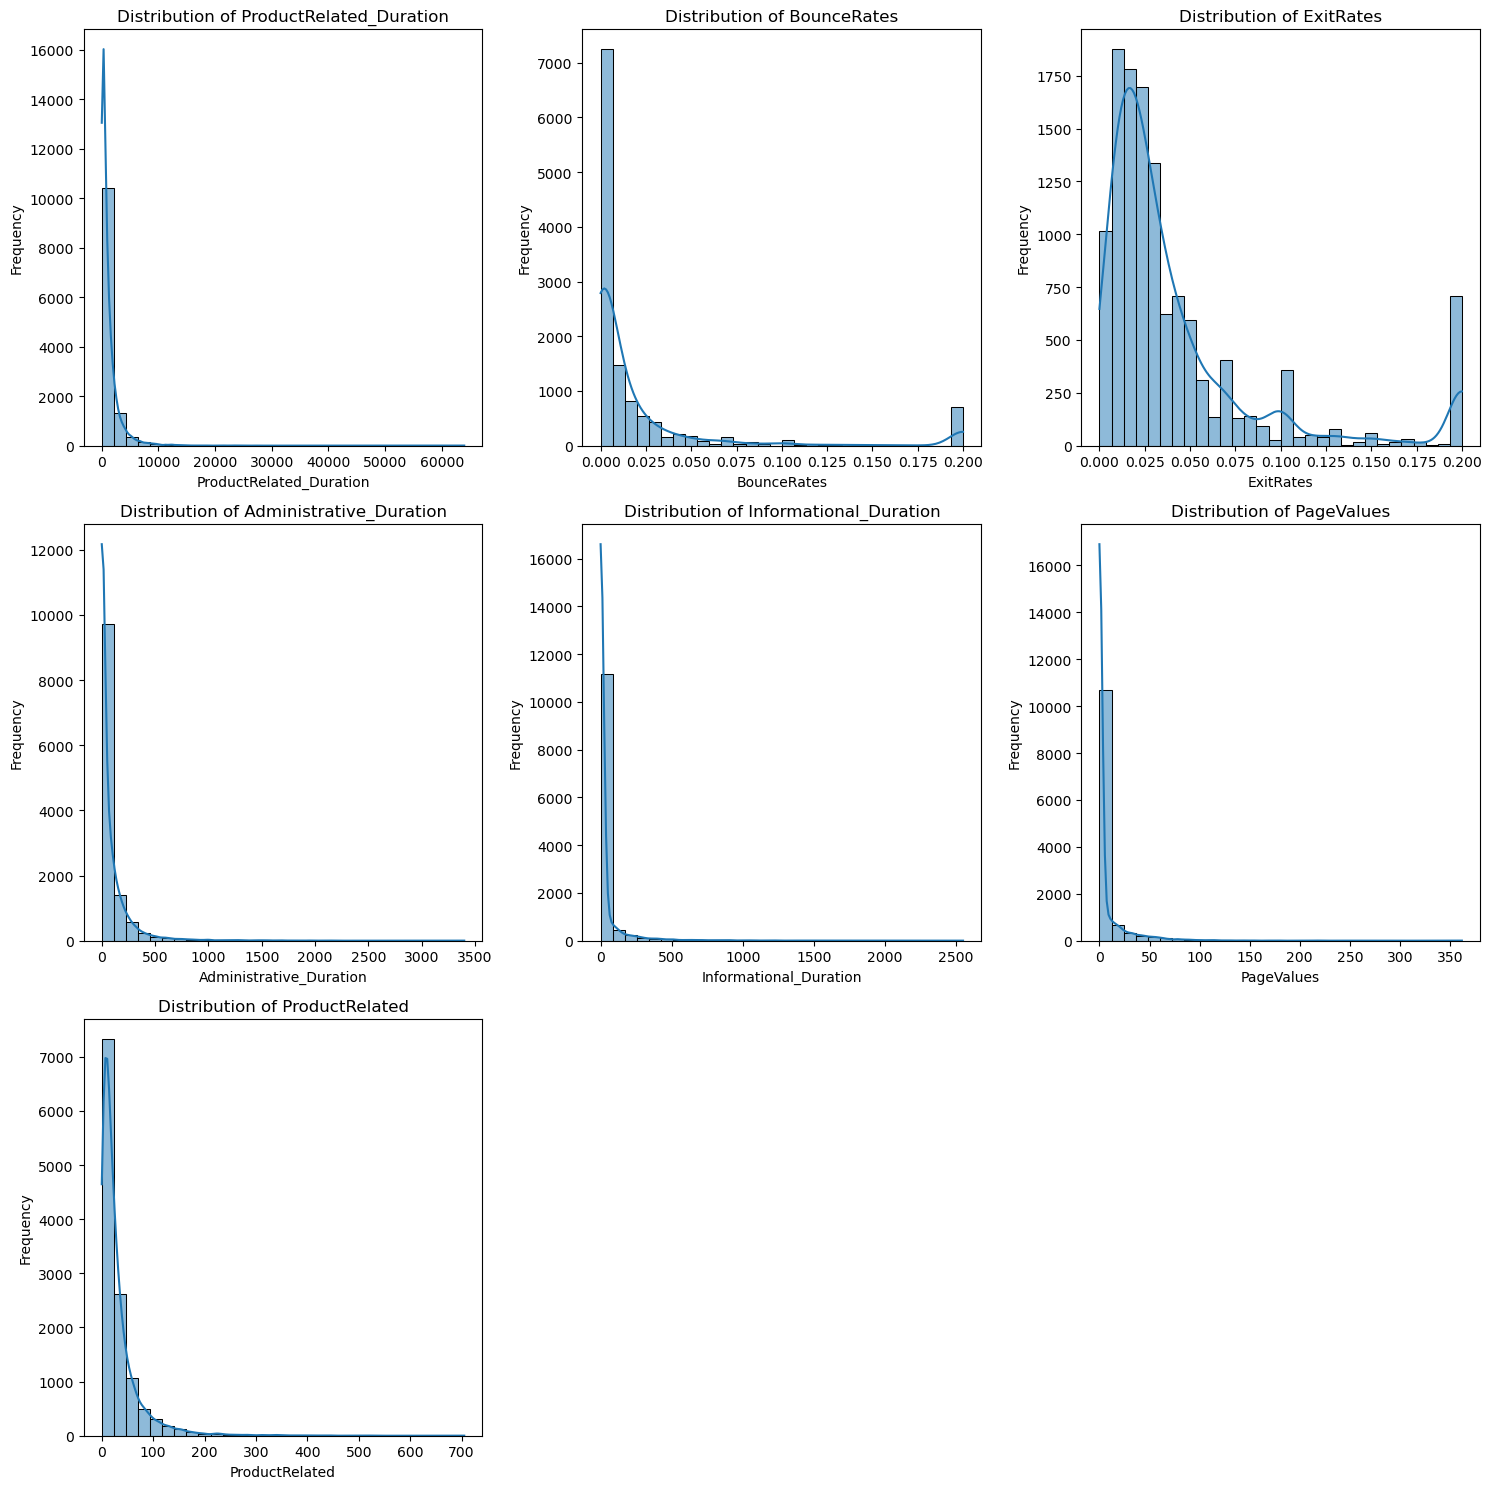

In [130]:
# histograms of continuous vars
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 15))
axes = axes.flatten()

for i, col in enumerate(continuous):
    sns.histplot(df[col], bins = 30, kde = True, ax = axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

axes[7].set_axis_off()
axes[8].set_axis_off()

plt.tight_layout()
plt.show()

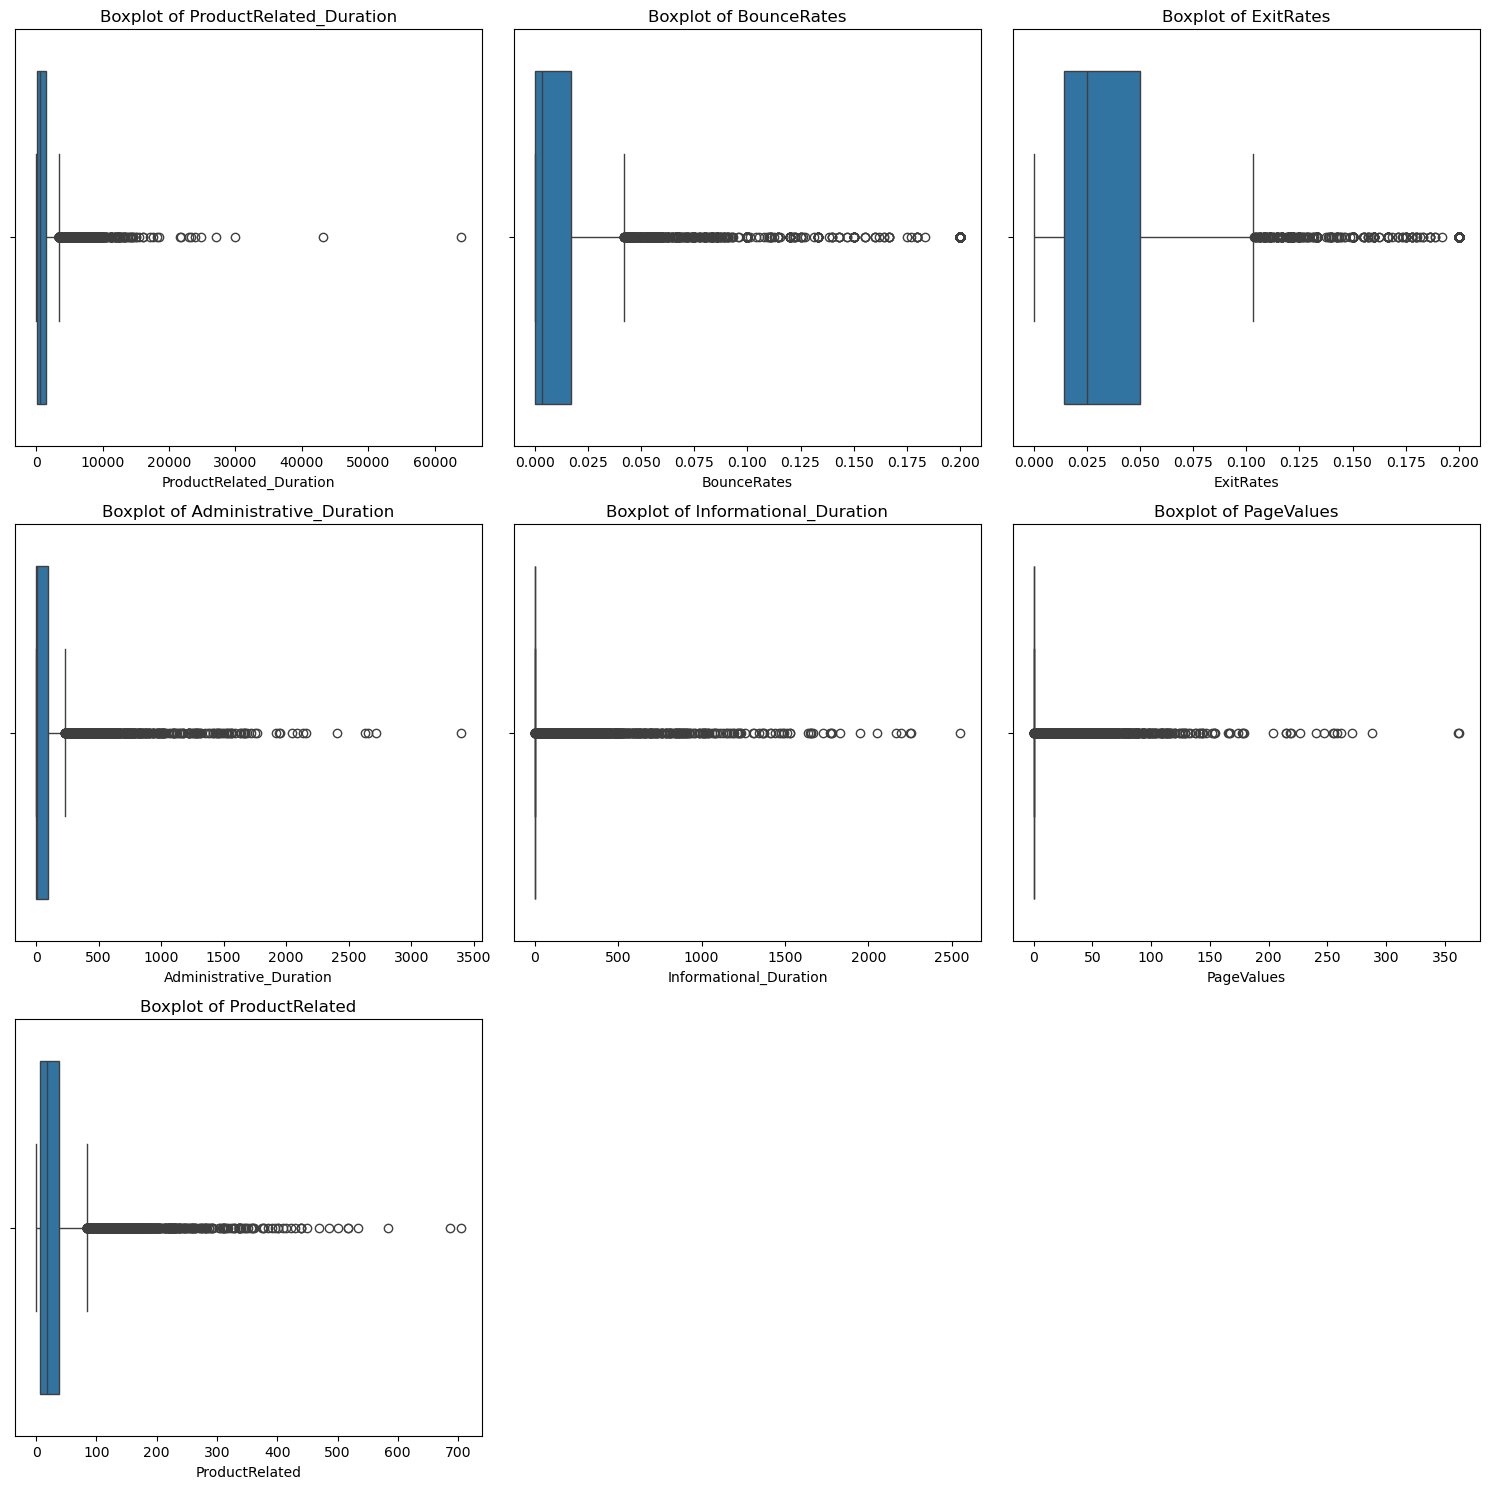

In [132]:
# boxplots of continuous vars
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 15))
axes = axes.flatten()

for i, col in enumerate(continuous):
    sns.boxplot(x = df[col], ax = axes[i])
    axes[i].set_title(f"Boxplot of {col}")

axes[7].set_axis_off()
axes[8].set_axis_off()

plt.tight_layout()
plt.show()

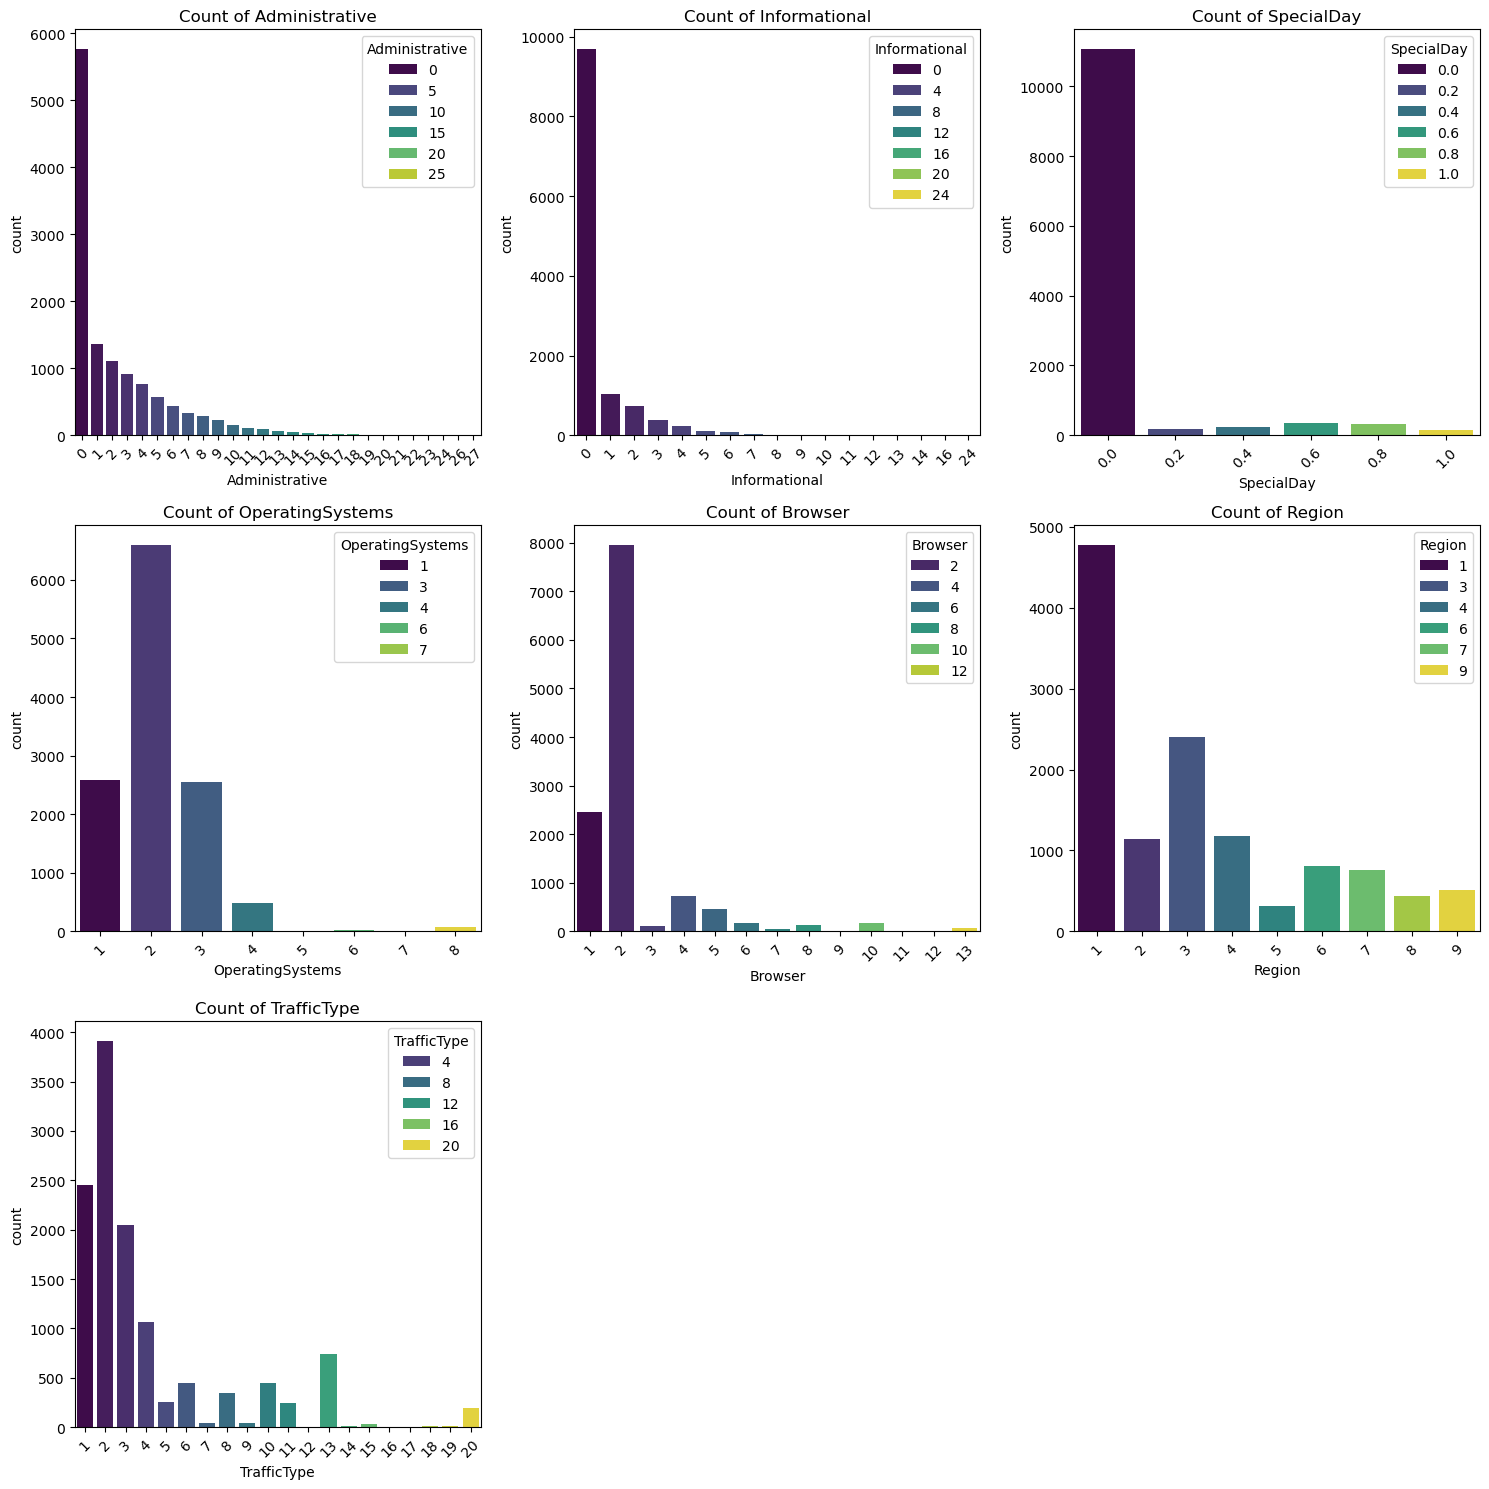

In [144]:
# barplots of discrete vars
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 15))
axes = axes.flatten()

for i, col in enumerate(discrete):
    sns.countplot(x = col, data = df, ax = axes[i], hue = col, palette = "viridis")
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis = 'x', rotation = 45)

axes[7].set_axis_off()
axes[8].set_axis_off()

plt.tight_layout()
plt.show()

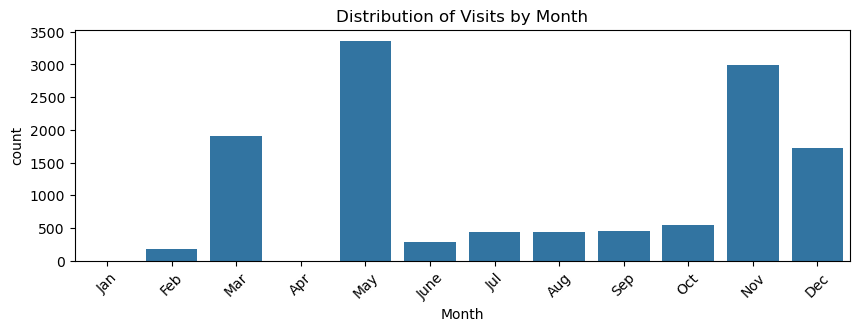

In [152]:
# month
plt.figure(figsize = (10, 3))
sns.countplot(x = "Month", data = df, order = ["Jan", "Feb", "Mar", "Apr", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.title("Distribution of Visits by Month")
plt.xticks(rotation = 45)
plt.show()

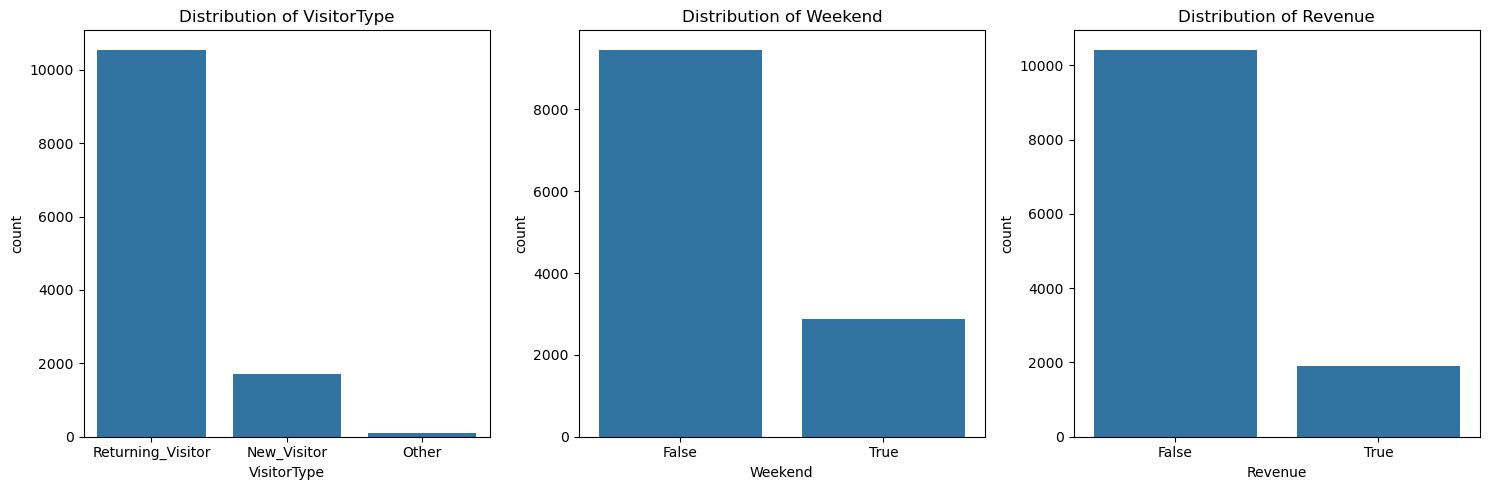

In [251]:
# barplots of nominal vars
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 5))
axes = axes.flatten()

for i, col in enumerate(nominal + target):
    sns.countplot(x = col, data = df, ax = axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

## Bivariate EDA

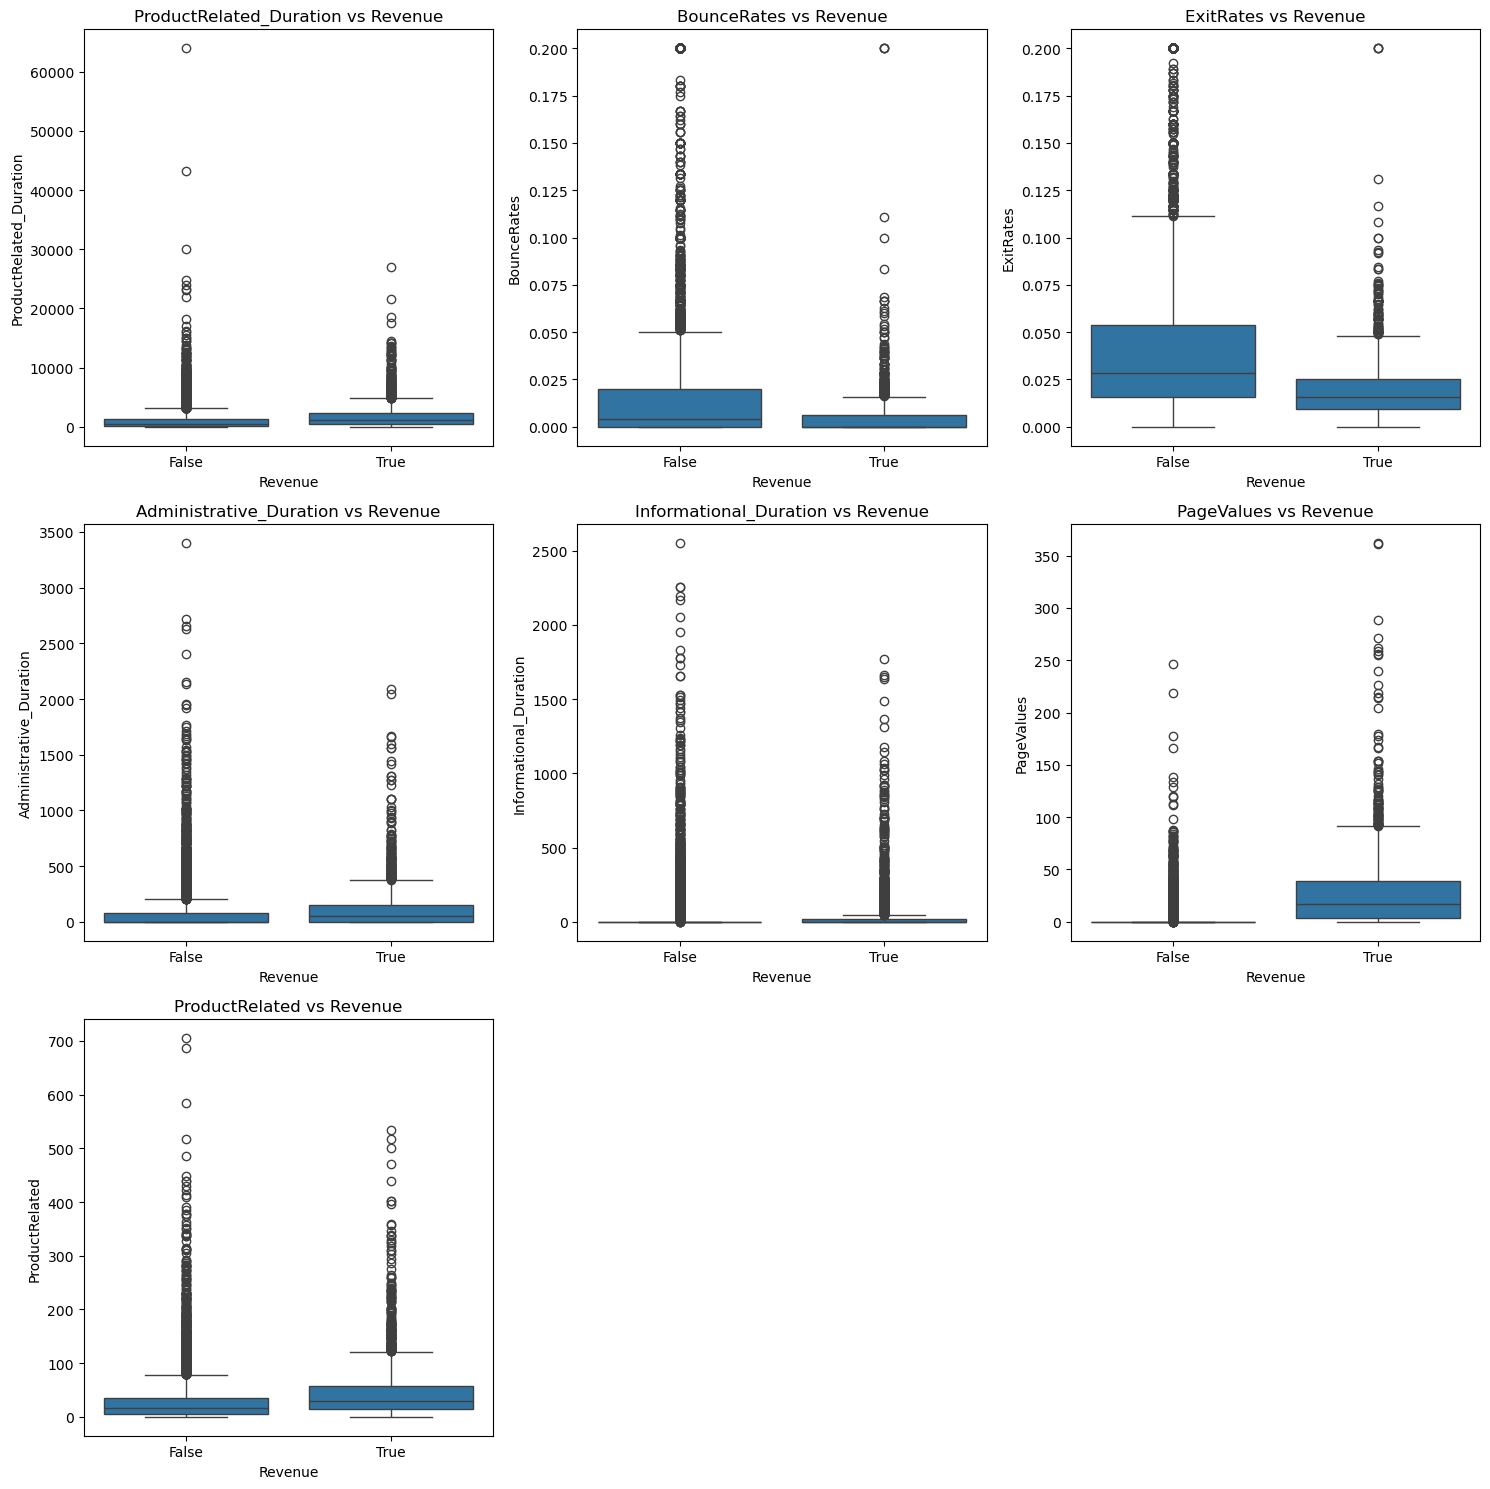

In [246]:
# continuous vars vs revenue
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 15))
axes = axes.flatten()

for i, col in enumerate(continuous):
    sns.boxplot(x = 'Revenue', y = col, data = df, ax = axes[i])
    axes[i].set_title(f'{col} vs Revenue')
    
axes[7].set_axis_off()
axes[8].set_axis_off()

plt.tight_layout()
plt.show()

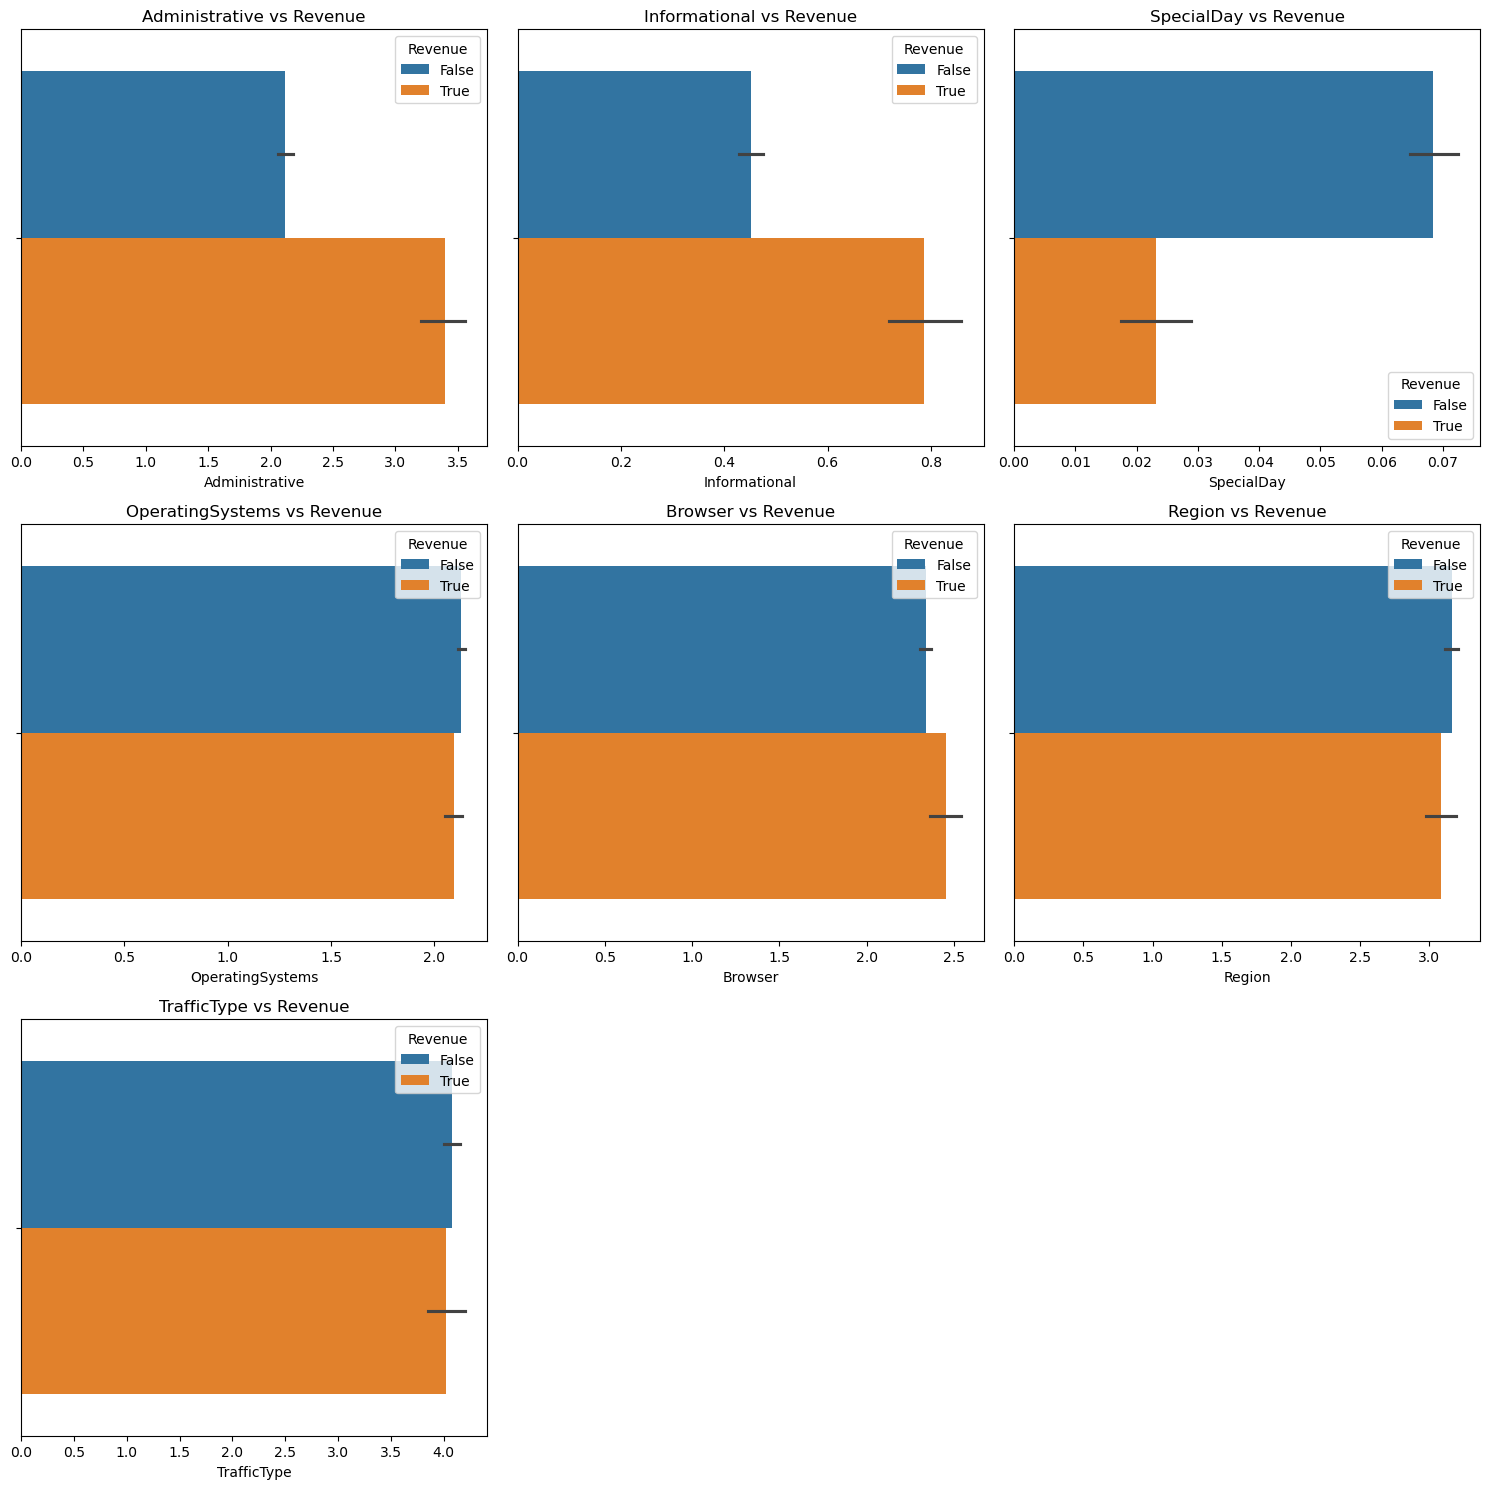

In [230]:
# discrete vars vs revenue
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 15))
axes = axes.flatten()

for i, col in enumerate(discrete):
    sns.barplot(x = df[col], hue = df["Revenue"], ax = axes[i])
    axes[i].set_title(f"{col} vs Revenue")

axes[7].set_axis_off()
axes[8].set_axis_off()

plt.tight_layout()
plt.show()

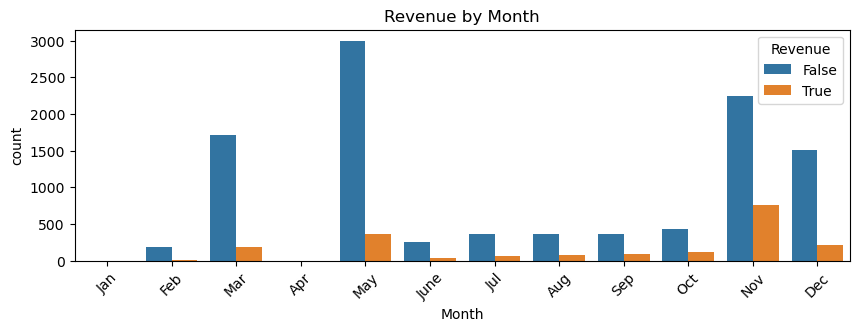

In [244]:
# month vs revenue
plt.figure(figsize = (10, 3))
sns.countplot(x = "Month", data = df, hue = "Revenue", order = ["Jan", "Feb", "Mar", "Apr", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.title("Revenue by Month")
plt.xticks(rotation = 45)
plt.show()

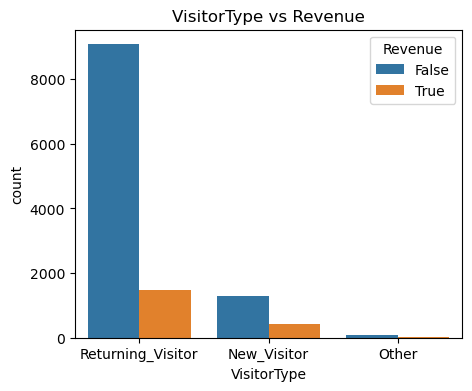

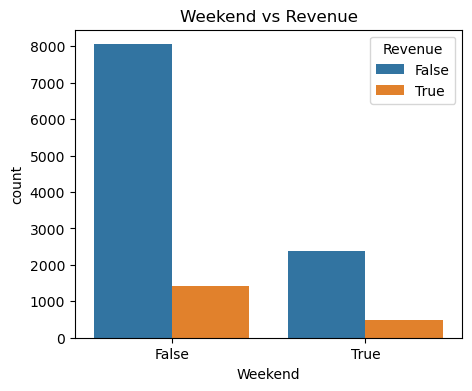

In [257]:
# nominal variables vs revenue

for var in nominal:
    plt.figure(figsize = (5, 4))
    sns.countplot(x=df[var], hue=df["Revenue"])
    plt.title(f"{var} vs Revenue")
    plt.show()

# Hypothesis Testing

## Hypotheses

The following hypothesis will assess the strength of relationships between key features and the likelihood of a purchase ('Revenue'). I will then perform statistical tests to validate the hypotheses and use visualizations for support. This will help determine if there are statistically significant differences between various groups.

#### Hypothesis 1: Time Spent on Website vs Purchase Behavior
- **Null Hypothesis (H0)**: There is no significant difference in the time spent on the website between users who made a purchase and users who did not.
- **Alternative Hypothesis (H1)**: Users who made a purchase spend significantly more time on the website than users who did not.

#### Hypothesis 2: Weekend Visits and Purchasing
- **Null Hypothesis (H0)**: There is no association between visiting the website on the weekend and making a purchase.
- **Alternative Hypothesis (H1)**: There is a significant association between visiting the website on the weekend and making a purchase.

## Testing

In [ ]:
# hypothesis 1: t-test
df["time"] = df["Administrative_Duration"] + df["Informational_Duration"] + df["ProductRelated_Duration"]

purchase = df[df['Revenue'] == True]
no_purchase = df[df['Revenue'] == False]

t_stat, p_val = stats.ttest_ind(purchase['time'], 
                                no_purchase['time'], 
                                equal_var = False)

print(f"T-test statistic: {t_stat}, p-value: {p_val}")

# hypothesis 1: spearman correlation
correlation, p_value = stats.spearmanr(df['time'], df['Revenue'])
print(f'Spearman Correlation: {correlation}, p-value: {p_value}')

T-test statistic: 14.936040814842574, P-value: 2.855260600162827e-48
Spearman Correlation: 0.22072148281922, p-value: 6.462910727016879e-136


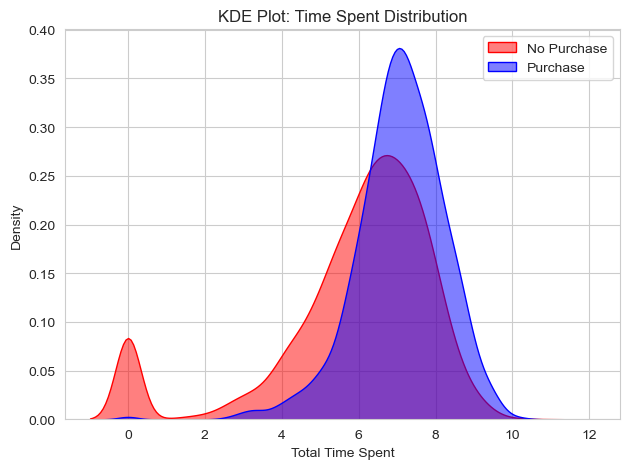

In [309]:
# hypothesis 1: KDE plot
df["log_time"] = np.log1p(df["time"])
purchase = df[df['Revenue'] == True]
no_purchase = df[df['Revenue'] == False]

sns.kdeplot(no_purchase["log_time"], label = "No Purchase", fill = True, color = "red", alpha = 0.5)
sns.kdeplot(purchase["log_time"], label = "Purchase", fill = True, color = "blue", alpha = 0.5)

plt.title("KDE Plot: Time Spent Distribution")
plt.xlabel("Total Time Spent")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

In [280]:
# hypothesis 2: chi-square
contingency_table = pd.crosstab(df['Weekend'], df['Revenue'])
chi2_stat, p_val, _, _ = stats.chi2_contingency(contingency_table)
print(f"Chi-square test statistic: {chi2_stat}, p-value: {p_val}")

Chi-square test statistic: 10.390978319534856, p-value: 0.0012663251061221983


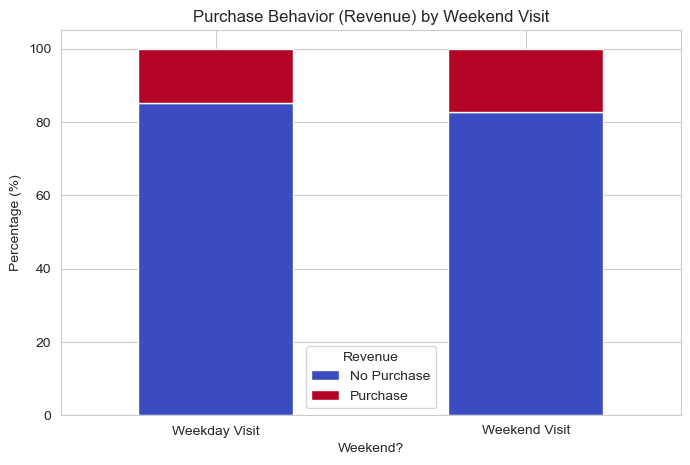

In [321]:
# hypothesis 2: stacked bar chart
weekend_revenue_counts = df.groupby(["Weekend", "Revenue"]).size().unstack()
weekend_revenue_percent = weekend_revenue_counts.div(weekend_revenue_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize = (8, 5))
weekend_revenue_percent.plot(kind = "bar", stacked = True, colormap = "coolwarm", ax = ax)

ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Weekend?")
ax.set_title("Purchase Behavior (Revenue) by Weekend Visit")
ax.legend(title = "Revenue", labels = ["No Purchase", "Purchase"])

plt.xticks(ticks = [0,1], labels = ["Weekday Visit", "Weekend Visit"], rotation = 0)
plt.show()

## Results

#### Hypothesis 1: Time Spent on Website vs Purchase Behavior
- **T-test statistic**: With a T-test statistic of 14.94, which is well above the common threshold for significance (typically around 2 for large sample sizes), the result indicates a substantial difference between the two groups, strongly rejecting the null hypothesis.
- **P-value (T-test)**: The P-value of 2.86e-48 is far below the commonly used significance threshold of 0.05, confirming that the difference in time spent on the website between users who made a purchase and those who did not is statistically significant.
- **Spearman Correlation**: A Spearman correlation of 0.22 is relatively low, but any correlation above 0.1 is often considered to indicate a weak positive relationship.
- **P-value (Spearman)**: The P-value of 6.46e-136 is extremely small and well below the standard threshold of 0.05, further confirming that the weak positive correlation between time spent on the website and purchase behavior is statistically meaningful.
- **KDE Plots**: The plots show differing distributions for purchase behavior, with purchasing consumers being more consistent (less variation) and spending slightly more time, while non-purchasing consumers are more likely to spend either less than a minute on the website or just less time on average than purchasing consumers. 
- **CONCLUSION**: The analysis strongly supports the hypothesis that users who made a purchase spent significantly more time on the website, with both the T-test and Spearman correlation revealing statistically significant results, and the KDE plots illustrating distinct patterns in time spent between purchasing and non-purchasing users.

#### Hypothesis 2: Weekend Visits and Purchasing
- **Chi-square test statistic**: The Chi-square test statistic of 10.39 exceeds the critical value (approximately 3.84 for a 0.05 significance level with 1 degree of freedom), indicating a significant difference between observed and expected frequencies, which leads to rejecting the null hypothesis.
- **P-value**: The P-value of 0.00127 is far below the commonly used significance threshold of 0.05, confirming that the observed association is statistically significant.
- **Stacked bar charts**: The ratios of consumers seem relatively similar whether or not it is a weekend, deceptively leading one to believe there is no statistically significant difference between purchasing on the weekend or on a weekday. 
- **CONCLUSION**: In conclusion, despite the visually similar ratios in the stacked bar charts, the Chi-square test reveals a statistically significant association between visiting the website on the weekend and making a purchase, rejecting the null hypothesis and indicating that weekend visits do influence purchasing behavior.

# Summary Report

#### Hypothesis 1: Time Spent on Website vs Purchase Behavior
The analysis confirms that users who made a purchase spent significantly more time on the website, as shown by the highly significant T-test and Spearman correlation. The KDE plots also reveal distinct patterns, with purchasing users being more consistent and spending slightly more time, while non-purchasing users tend to spend less time or show more variation.

#### Hypothesis 2: Weekend Visits and Purchasing
Although the stacked bar charts show similar ratios of consumers who make purchases on weekends and weekdays, the Chi-square test reveals a statistically significant association between weekend visits and purchasing behavior. This result rejects the null hypothesis, confirming that weekend visits do influence the likelihood of making a purchase.